In [1]:
# ==============================================================================
# CÀI RIÊNG LẺ ĐỂ TRÁNH XUNG ĐỘT (DEPENDENCY HELL)
# ==============================================================================

# 1. Cài Underthesea TRƯỚC (Để lấy bản mới nhất 8.3.0 hỗ trợ Python 3.12)
# Lúc này nó sẽ tự cài Numpy 2.0 
!pip install underthesea

# 2. SAU ĐÓ ép hạ cấp Numpy và Scikit-learn về bản cũ
# Lệnh này sẽ đè lên bản Numpy 2.0 vừa cài ở trên. 
# Pip sẽ báo lỗi đỏ (ERROR) về conflict, nhưng code vẫn sẽ chạy được.
!pip install numpy<2.0.0 scipy<1.13.0 scikit-learn<1.6.0 imbalanced-learn seaborn torch

# ==============================================================================
# KIỂM TRA KẾT QUẢ
# ==============================================================================
import numpy as np
import underthesea
import sklearn
from underthesea import word_tokenize

print("-" * 30)
print(f"✅ Numpy Version: {np.__version__}")       # Phải là 1.26.x
print(f"✅ Underthesea: {underthesea.__version__}") # Phải là 8.3.x
print(f"✅ Sklearn Version: {sklearn.__version__}") # Phải là 1.5.x
print("-" * 30)
print(f"✅ Test token: {word_tokenize('Chạy ngon lành cành đào')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 79.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.5 MB/s eta 0:00:00
/bin/bash: line 1: 2.0.0: No such file or directory
------------------------------
✅ Numpy Version: 2.0.2
✅ Underthesea: 8.3.0
✅ Sklearn Version: 1.6.1
------------------------------
✅ Test token: ['Chạy', 'ngon lành', 'cành', 'đào']


In [33]:
import os
import pandas as pd
# ======================================================
# BƯỚC 2: TỰ ĐỘNG TÌM FILE TRONG INPUT
# ======================================================
print("Đang quét thư mục Input để tìm file dữ liệu...")

train_df, dev_df, test_df = None, None, None

# Quét tất cả file trong /kaggle/input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        lower_name = filename.lower()
        
        # Logic tìm file dựa trên tên
        if 'train' in lower_name:
            print(f"-> Đã tìm thấy tập TRAIN: {path}")
            train_df = pd.read_csv(path)
        elif 'dev' in lower_name or 'val' in lower_name:
            print(f"-> Đã tìm thấy tập DEV/VALIDATION: {path}")
            dev_df = pd.read_csv(path)
        elif 'test' in lower_name:
            print(f"-> Đã tìm thấy tập TEST: {path}")
            test_df = pd.read_csv(path)
# Xử lý NaN và ép kiểu chuỗi cho CẢ Train và Test
train_df['clean_text'] = train_df['clean_text'].fillna('').astype(str)
test_df['clean_text'] = test_df['clean_text'].fillna('').astype(str)

print(f"Số lượng mẫu Train: {len(train_df)}")
print(f"Số lượng mẫu Test:  {len(test_df)}")
# Kiểm tra xem đã load đủ chưa
if train_df is None or test_df is None:
    raise ValueError("LỖI: Không tìm thấy file 'train' hoặc 'test' trong Input. Bạn đã upload thành công chưa?")
else:
    print("Load dữ liệu thành công!")

Đang quét thư mục Input để tìm file dữ liệu...
-> Đã tìm thấy tập TRAIN: /kaggle/input/vihsd-clean/train_cleaned.csv
-> Đã tìm thấy tập TEST: /kaggle/input/vihsd-clean/test_cleaned.csv
-> Đã tìm thấy tập DEV/VALIDATION: /kaggle/input/vihsd-clean/dev_cleaned.csv
Số lượng mẫu Train: 43886
Số lượng mẫu Test:  6680
Load dữ liệu thành công!


In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pickle
import numpy as np
import os
import pandas as pd
from collections import Counter
import copy # Dùng để lưu trạng thái tốt nhất

# ===============================
# 1. CẤU HÌNH & THIẾT BỊ
# ===============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# ===============================
# 2. HÀM XỬ LÝ TEXT (Pipeline)
# ===============================
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())
    
    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

def text_pipeline(text, vocab, max_len):
    text = str(text).lower() 
    tokens = text.split()
    indices = [vocab.get(token, 1) for token in tokens]
    
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
        
    return torch.tensor(indices, dtype=torch.long)

# ===============================
# 3. DATASET & MODEL
# ===============================
class ToxicDataset(Dataset):
    def __init__(self, df, vocab, max_len=100):
        self.texts = df['clean_text'].values
        
        # Tự động tìm cột label (hỗ trợ cả label_id và label)
        if 'label_id' in df.columns:
            self.labels = df['label_id'].values
        elif 'label' in df.columns:
             self.labels = df['label'].values
        else:
            self.labels = np.zeros(len(df), dtype=int)
            
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        input_tensor = text_pipeline(text, self.vocab, self.max_len)
        return input_tensor, torch.tensor(label, dtype=torch.long)

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True, dropout=0.3, num_layers=2)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        hidden = self.dropout(hidden)
        logits = self.fc(hidden)
        return logits

# ===============================
# 4. CHUẨN BỊ DỮ LIỆU
# ===============================
# Kiểm tra biến train_df
if 'train_df' in globals():
    train_df['clean_text'] = train_df['clean_text'].fillna('').astype(str)
else:
    raise NameError("❌ LỖI: Không tìm thấy biến 'train_df'. Bạn cần load file CSV vào biến train_df trước!")

if 'dev_df' in globals() and dev_df is not None:
    dev_df['clean_text'] = dev_df['clean_text'].fillna('').astype(str)

print("Đang xây dựng từ điển (Vocab)...")
vocab = build_vocab(train_df['clean_text'])
print(f"Kích thước từ điển: {len(vocab)}")

num_classes = 3 

# Tạo Dataset
full_dataset = ToxicDataset(train_df, vocab)

if 'dev_df' in globals() and dev_df is not None:
    print("Sử dụng tập dev_df riêng biệt làm Validation.")
    train_ds = ToxicDataset(train_df, vocab)
    val_ds = ToxicDataset(dev_df, vocab)
else:
    print("Không có dev_df, tự động chia 80/20 từ train_df.")
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# ===============================
# 5. HUẤN LUYỆN (OPTIMIZED LOOP)
# ===============================
model = BiLSTM(vocab_size=len(vocab), num_classes=num_classes).to(device)

# [QUAN TRỌNG] Class Weights: Phạt nặng model gấp 4-5 lần nếu đoán sai Hate/Offensive
# Giúp tăng khả năng bắt được comment độc hại
class_weights = torch.tensor([1.0, 5.0, 4.0]).to(device) 
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15
best_val_loss = float('inf')
best_model_state = None

# Danh sách lưu lịch sử (để vẽ biểu đồ sau này)
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"\n Bắt đầu huấn luyện {num_epochs} Epochs...")

for epoch in range(num_epochs):
    # ---- Train ----
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    
    # ---- Validation ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)
            
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    
    # Lưu lịch sử
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    # [CHECKPOINT] Lưu model tốt nhất (Val Loss thấp nhất)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  --> New Best Model! (Loss giảm từ {best_val_loss if best_val_loss != val_loss else 'inf'} xuống {val_loss:.4f})")

# ===============================
# 6. LƯU MODEL RA FILE
# ===============================
print("\n Kết thúc huấn luyện.")

if best_model_state is not None:
    print(f"Đang khôi phục lại trạng thái tốt nhất (Best Val Loss: {best_val_loss:.4f})...")
    model.load_state_dict(best_model_state)
else:
    print("⚠️ Không tìm thấy model tốt hơn, dùng model ở epoch cuối.")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "max_len": 100,
    "num_classes": num_classes
}

# Lưu file với tên bạn yêu cầu
save_path = "bi_lstm_vihsd_groupdata_merge.pkl"
with open(save_path, "wb") as f:
    pickle.dump(checkpoint, f)

print(f"Đã lưu model thành công tại: {os.path.abspath(save_path)}")

 Using device: cuda
Đang xây dựng từ điển (Vocab)...
Kích thước từ điển: 10343
Sử dụng tập dev_df riêng biệt làm Validation.

 Bắt đầu huấn luyện 15 Epochs...
Epoch 01/15 | Train Loss: 0.6120 Acc: 0.6659 | Val Loss: 1.0360 Acc: 0.7081
  --> New Best Model! (Loss giảm từ inf xuống 1.0360)
Epoch 02/15 | Train Loss: 0.2788 Acc: 0.8536 | Val Loss: 0.9960 Acc: 0.7758
  --> New Best Model! (Loss giảm từ inf xuống 0.9960)
Epoch 03/15 | Train Loss: 0.1679 Acc: 0.9087 | Val Loss: 1.2413 Acc: 0.7736
Epoch 04/15 | Train Loss: 0.1188 Acc: 0.9363 | Val Loss: 1.1404 Acc: 0.7773
Epoch 05/15 | Train Loss: 0.0895 Acc: 0.9517 | Val Loss: 1.3260 Acc: 0.8219
Epoch 06/15 | Train Loss: 0.0691 Acc: 0.9629 | Val Loss: 1.6163 Acc: 0.8256
Epoch 07/15 | Train Loss: 0.0615 Acc: 0.9679 | Val Loss: 1.5753 Acc: 0.8125
Epoch 08/15 | Train Loss: 0.0498 Acc: 0.9745 | Val Loss: 1.6619 Acc: 0.8136
Epoch 09/15 | Train Loss: 0.0415 Acc: 0.9788 | Val Loss: 1.8011 Acc: 0.8166
Epoch 10/15 | Train Loss: 0.0375 Acc: 0.9807 | Va

Đang lấy dự đoán từ tập Validation/Test...

✅ ĐỘ CHÍNH XÁC (ACCURACY): 77.58%

--- BÁO CÁO CHI TIẾT TỪNG LỚP ---
               precision    recall  f1-score   support

    Clean (0)       0.93      0.83      0.88      2190
Offensive (1)       0.34      0.44      0.38       212
     Hate (2)       0.37      0.60      0.46       270

     accuracy                           0.78      2672
    macro avg       0.55      0.62      0.57      2672
 weighted avg       0.82      0.78      0.79      2672

F1-Score Macro: 0.5724


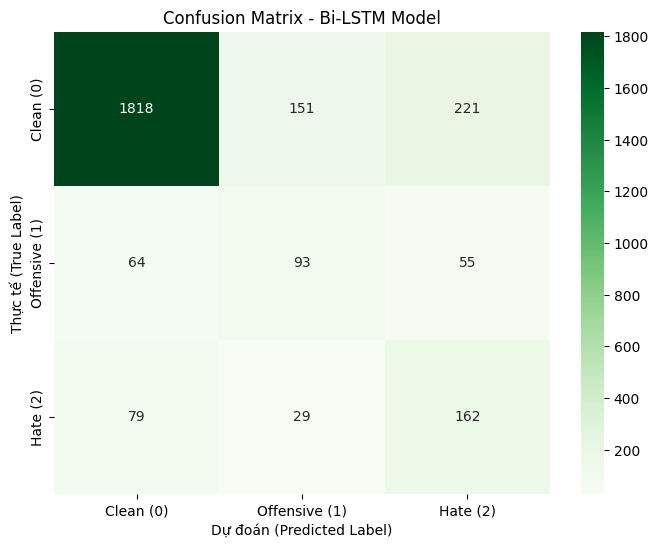

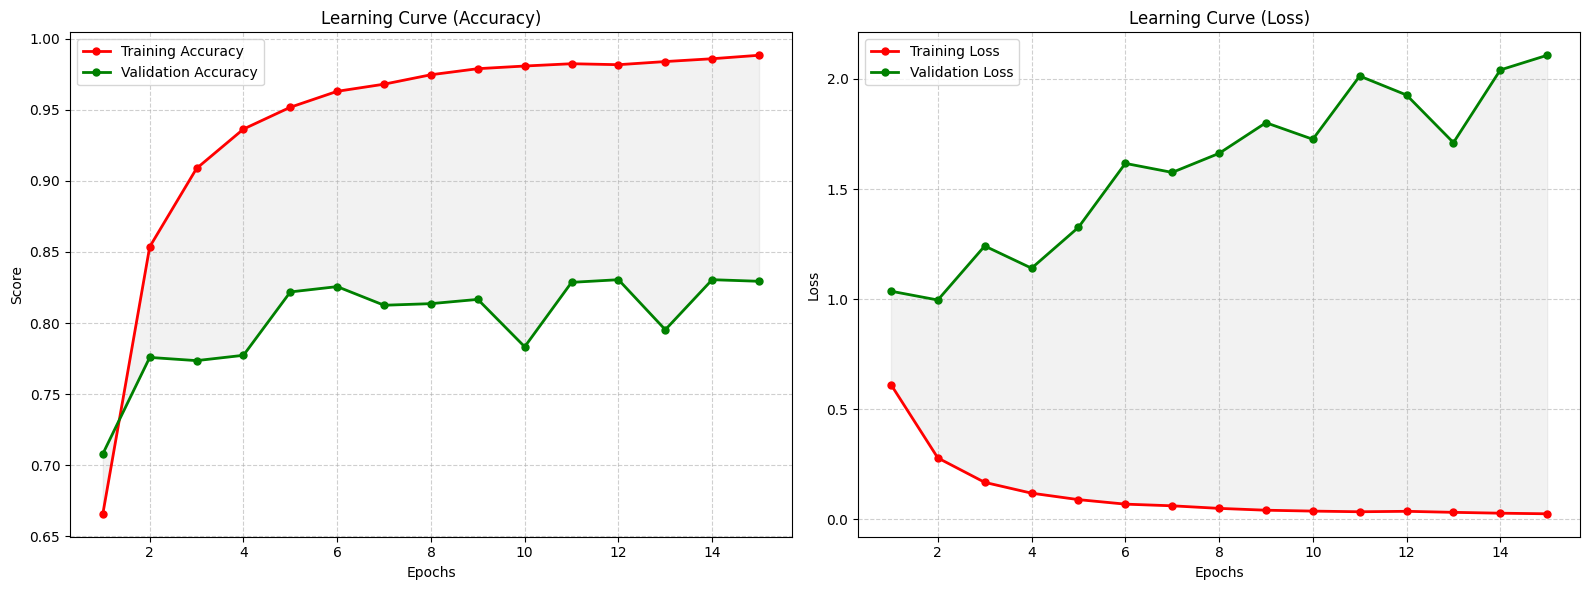

In [35]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import torch

# ======================================================
# 1. HÀM LẤY DỰ ĐOÁN TỪ MODEL (PyTorch)
# ======================================================
def get_predictions(model, loader, device):
    model.eval() # Chuyển sang chế độ đánh giá (tắt Dropout)
    all_preds = []
    all_labels = []
    
    print("Đang lấy dự đoán từ tập Validation/Test...")
    with torch.no_grad(): # Tắt tính toán gradient để tiết kiệm bộ nhớ
        for x, y in loader:
            x = x.to(device)
            y = y.to(device) # Đưa label lên device để đồng bộ (nếu cần)
            
            # Chạy qua model
            logits = model(x)
            
            # Lấy nhãn có xác suất cao nhất (argmax)
            preds = torch.argmax(logits, dim=1)
            
            # Đưa về CPU và lưu lại dưới dạng numpy array
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

# ==========================================================
# 2. THỰC HIỆN ĐÁNH GIÁ
# ==========================================================
# Lấy dữ liệu thật (y_true) và dự đoán (y_pred) từ val_loader
# Lưu ý: Nếu bạn có test_loader riêng, hãy thay val_loader bằng test_loader
y_true, y_pred = get_predictions(model, val_loader, device)

# --- Tính Accuracy ---
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ ĐỘ CHÍNH XÁC (ACCURACY): {acc*100:.2f}%")

# --- Báo cáo chi tiết (Precision, Recall, F1-Score) ---
print("\n--- BÁO CÁO CHI TIẾT TỪNG LỚP ---")

# Tự động đặt tên lớp dựa trên số lượng class
if num_classes == 3:
    target_names = ['Clean (0)', 'Offensive (1)', 'Hate (2)']
else:
    target_names = [f'Class {i}' for i in range(num_classes)]

print(classification_report(y_true, y_pred, target_names=target_names))

# --- F1-Score Macro ---
f1 = f1_score(y_true, y_pred, average='macro')
print(f"F1-Score Macro: {f1:.4f}")

# ======================================================
# 3. VẼ CONFUSION MATRIX 
# ======================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names,
            yticklabels=target_names)

plt.title('Confusion Matrix - Bi-LSTM Model')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.show()

# ======================================================
# 4. VẼ LEARNING CURVE (Epochs vs Accuracy/Loss)
# ======================================================

def plot_dl_learning_curve_styled(train_accs, val_accs, train_losses, val_losses):
    # Kiểm tra dữ liệu
    if not train_accs or len(train_accs) == 0:
        print("⚠️ Không có dữ liệu lịch sử huấn luyện.")
        return

    epochs = range(1, len(train_accs) + 1)
    
    plt.figure(figsize=(16, 6))

    # ==========================================
    # 1. BIỂU ĐỒ ACCURACY 
    # ==========================================
    plt.subplot(1, 2, 1)
    plt.title("Learning Curve (Accuracy)")
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.grid(True, linestyle='--', alpha=0.6)

    # Vẽ đường Train (Màu Đỏ)
    plt.plot(epochs, train_accs, 'o-', color="r", label="Training Accuracy", linewidth=2, markersize=5)
    
    # Vẽ đường Val (Màu Xanh lá)
    plt.plot(epochs, val_accs, 'o-', color="g", label="Validation Accuracy", linewidth=2, markersize=5)
    
    # Tạo vùng mờ nhẹ giữa 2 đường để dễ nhìn khoảng cách (giả lập fill_between)
    plt.fill_between(epochs, train_accs, val_accs, color="gray", alpha=0.1)

    plt.legend(loc="best")

    # ==========================================
    # 2. BIỂU ĐỒ LOSS
    # ==========================================
    plt.subplot(1, 2, 2)
    plt.title("Learning Curve (Loss)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.6)

    # Vẽ đường Train (Màu Đỏ)
    plt.plot(epochs, train_losses, 'o-', color="r", label="Training Loss", linewidth=2, markersize=5)
    
    # Vẽ đường Val (Màu Xanh lá)
    plt.plot(epochs, val_losses, 'o-', color="g", label="Validation Loss", linewidth=2, markersize=5)
    
    # Tạo vùng mờ nhẹ
    plt.fill_between(epochs, train_losses, val_losses, color="gray", alpha=0.1)

    plt.legend(loc="best")
    
    plt.tight_layout()
    plt.show()

# --- CHẠY HÀM VẼ ---
# Đảm bảo bạn đã chạy xong vòng lặp huấn luyện ở trên và có biến train_accs, val_accs...
if 'train_accs' in globals() and len(train_accs) > 0:
    plot_dl_learning_curve_styled(train_accs, val_accs, train_losses, val_losses)
else:
    print("⚠️ Chưa tìm thấy dữ liệu huấn luyện. Hãy chạy vòng lặp Training trước!")

In [36]:
import pandas as pd

# ==========================================================
# 1. CHUẨN BỊ DỮ LIỆU PHÂN TÍCH
# ==========================================================

# --- BƯỚC QUAN TRỌNG: KIỂM TRA BIẾN ---
# Mục đích: Tự động chọn đúng biến dữ liệu bạn đang có (test_df hoặc val_df)
if 'test_df' in globals():
    source_df = test_df
    print("✅ Đang sử dụng dữ liệu từ 'test_df'")
elif 'val_df' in globals():
    source_df = val_df
    print("✅ Đang sử dụng dữ liệu từ 'val_df'")
else:
    raise NameError("❌ Lỗi: Không tìm thấy cả 'test_df' lẫn 'val_df'. Hãy chạy lại cell chia dữ liệu (train_test_split)!")

# 1. Reset index để khớp với mảng dự đoán (y_pred)
analyze_df = source_df.copy().reset_index(drop=True)

# 2. Gán nhãn thực tế và nhãn dự đoán (Đảm bảo độ dài khớp nhau)
if len(analyze_df) != len(y_true):
    print(f"⚠️ CẢNH BÁO: Độ dài dữ liệu ({len(analyze_df)}) khác độ dài dự đoán ({len(y_true)}).")
    # Cắt dataframe cho khớp nếu bị lệch (thường ít khi xảy ra nếu làm đúng)
    analyze_df = analyze_df.iloc[:len(y_true)]

analyze_df['label_id_true'] = y_true
analyze_df['label_id_pred'] = y_pred

# 3. Map tên nhãn để dễ đọc
label_map = {0: 'Clean', 1: 'Offensive', 2: 'Hate'}
analyze_df['label_name_true'] = analyze_df['label_id_true'].map(label_map)
analyze_df['label_name_pred'] = analyze_df['label_id_pred'].map(label_map)

# 4. Lọc ra các câu dự đoán SAI
wrong_df = analyze_df[analyze_df['label_id_true'] != analyze_df['label_id_pred']]

print(f"\n TỔNG KẾT LỖI:")
print(f"- Tổng số câu: {len(analyze_df)}")
print(f"- Số câu sai: {len(wrong_df)}")
print(f"- Tỷ lệ sai: {len(wrong_df)/len(analyze_df)*100:.2f}%")

# ==========================================================
# 2. IN CÁC VÍ DỤ ĐIỂN HÌNH
# ==========================================================

def print_errors(title, true_label, pred_label, df, limit=3):
    print(f"\n{'='*10} {title} {'='*10}")
    # Lọc theo điều kiện
    subset = df[(df['label_id_true'] == true_label) & (df['label_id_pred'] == pred_label)]
    
    if subset.empty:
        print("✅ Không tìm thấy trường hợp nào.")
    else:
        for i, row in enumerate(subset['clean_text'].head(limit)):
            print(f"{i+1}. {row}")
        print(f"... (Còn {len(subset) - limit} trường hợp nữa)" if len(subset) > limit else "")

# Case 1: False Positive
print_errors("CASE 1: SẠCH bị đoán nhầm là HATE", 
             true_label=0, pred_label=2, df=wrong_df)

# Case 2: False Negative
print_errors("CASE 2: HATE bị đoán nhầm là SẠCH", 
             true_label=2, pred_label=0, df=wrong_df)

# Case 3: Confusing
print_errors("CASE 3: OFFENSIVE bị đoán nhầm là HATE", 
             true_label=1, pred_label=2, df=wrong_df)

# ==========================================================
# 3. XUẤT FILE CSV ĐỂ BÁO CÁO
# ==========================================================
output_cols = ['clean_text', 'label_name_true', 'label_name_pred']
filename = 'bi_lstm_error_analysis.csv'

# Kiểm tra xem có dữ liệu lỗi để lưu không
if not wrong_df.empty:
    wrong_df[output_cols].to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\n💾 Đã lưu danh sách {len(wrong_df)} câu sai vào file '{filename}'")
    print("\n--- Preview dữ liệu lỗi ---")
    print(wrong_df[output_cols].head())
else:
    print("\n Model dự đoán đúng 100%, không có file lỗi nào được tạo.")

✅ Đang sử dụng dữ liệu từ 'test_df'
⚠️ CẢNH BÁO: Độ dài dữ liệu (6680) khác độ dài dự đoán (2672).

 TỔNG KẾT LỖI:
- Tổng số câu: 2672
- Số câu sai: 599
- Tỷ lệ sai: 22.42%

========== CASE 1: SẠCH bị đoán nhầm là HATE ==========
1. coin card : 3
2. được đấy abe
3. đề_nghị 17 , 22,23,32 đến phà vài hơi vào mẹt tk này để nó đi cách_ly thế_giới hẳn đi .
... (Còn 218 trường hợp nữa)

========== CASE 2: HATE bị đoán nhầm là SẠCH ==========
1. hanh viet hết cái bọn cực_kì thuyết_phục bây_giờ lại đến bọn : “ ở nhà giúp mẹ giúp cha . “ xàm lol như nhau cả thôi
2. trai hay gái ?
3. cô nói_chuyện cưng quá à
... (Còn 76 trường hợp nữa)

========== CASE 3: OFFENSIVE bị đoán nhầm là HATE ==========
1. chán thực_sự = )
2. éo thích thì biến đi thọc con mắt chóng cái tai lên xem làm ghì
3. nặc na tao cũng không bình thường nữa 😁
... (Còn 52 trường hợp nữa)

💾 Đã lưu danh sách 599 câu sai vào file 'bi_lstm_error_analysis.csv'

--- Preview dữ liệu lỗi ---
                                        clean_t

# **ALL-IN-ONE VERSION**
```python
# ==============================================================================
# CÀI RIÊNG LẺ ĐỂ TRÁNH XUNG ĐỘT (DEPENDENCY HELL)
# ==============================================================================

# 1. Cài Underthesea TRƯỚC (Để lấy bản mới nhất 8.3.0 hỗ trợ Python 3.12)
# Lúc này nó sẽ tự cài Numpy 2.0 
!pip install underthesea

# 2. SAU ĐÓ ép hạ cấp Numpy và Scikit-learn về bản cũ
# Lệnh này sẽ đè lên bản Numpy 2.0 vừa cài ở trên. 
# Pip sẽ báo lỗi đỏ (ERROR) về conflict, nhưng code vẫn sẽ chạy được.
!pip install numpy<2.0.0 scipy<1.13.0 scikit-learn<1.6.0 imbalanced-learn seaborn torch

# ==============================================================================
# KIỂM TRA KẾT QUẢ
# ==============================================================================
import numpy as np
import underthesea
import sklearn
from underthesea import word_tokenize

print("-" * 30)
print(f"✅ Numpy Version: {np.__version__}")       # Phải là 1.26.x
print(f"✅ Underthesea: {underthesea.__version__}") # Phải là 8.3.x
print(f"✅ Sklearn Version: {sklearn.__version__}") # Phải là 1.5.x
print("-" * 30)
print(f"✅ Test token: {word_tokenize('Chạy ngon lành cành đào')}")


import os
import pandas as pd
# ======================================================
# BƯỚC 2: TỰ ĐỘNG TÌM FILE TRONG INPUT
# ======================================================
print("Đang quét thư mục Input để tìm file dữ liệu...")

train_df, dev_df, test_df = None, None, None

# Quét tất cả file trong /kaggle/input
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        lower_name = filename.lower()
        
        # Logic tìm file dựa trên tên
        if 'train' in lower_name:
            print(f"-> Đã tìm thấy tập TRAIN: {path}")
            train_df = pd.read_csv(path)
        elif 'dev' in lower_name or 'val' in lower_name:
            print(f"-> Đã tìm thấy tập DEV/VALIDATION: {path}")
            dev_df = pd.read_csv(path)
        elif 'test' in lower_name:
            print(f"-> Đã tìm thấy tập TEST: {path}")
            test_df = pd.read_csv(path)
# Xử lý NaN và ép kiểu chuỗi cho CẢ Train và Test
train_df['clean_text'] = train_df['clean_text'].fillna('').astype(str)
test_df['clean_text'] = test_df['clean_text'].fillna('').astype(str)

print(f"Số lượng mẫu Train: {len(train_df)}")
print(f"Số lượng mẫu Test:  {len(test_df)}")
# Kiểm tra xem đã load đủ chưa
if train_df is None or test_df is None:
    raise ValueError("LỖI: Không tìm thấy file 'train' hoặc 'test' trong Input. Bạn đã upload thành công chưa?")
else:
    print("Load dữ liệu thành công!")


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pickle
import numpy as np
import os
import pandas as pd
from collections import Counter
import copy # Dùng để lưu trạng thái tốt nhất

# ===============================
# 1. CẤU HÌNH & THIẾT BỊ
# ===============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# ===============================
# 2. HÀM XỬ LÝ TEXT (Pipeline)
# ===============================
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())
    
    vocab = {"<PAD>": 0, "<UNK>": 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

def text_pipeline(text, vocab, max_len):
    text = str(text).lower() 
    tokens = text.split()
    indices = [vocab.get(token, 1) for token in tokens]
    
    if len(indices) < max_len:
        indices += [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
        
    return torch.tensor(indices, dtype=torch.long)

# ===============================
# 3. DATASET & MODEL
# ===============================
class ToxicDataset(Dataset):
    def __init__(self, df, vocab, max_len=100):
        self.texts = df['clean_text'].values
        
        # Tự động tìm cột label (hỗ trợ cả label_id và label)
        if 'label_id' in df.columns:
            self.labels = df['label_id'].values
        elif 'label' in df.columns:
             self.labels = df['label'].values
        else:
            self.labels = np.zeros(len(df), dtype=int)
            
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        input_tensor = text_pipeline(text, self.vocab, self.max_len)
        return input_tensor, torch.tensor(label, dtype=torch.long)

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True, dropout=0.3, num_layers=2)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)
        hidden = self.dropout(hidden)
        logits = self.fc(hidden)
        return logits

# ===============================
# 4. CHUẨN BỊ DỮ LIỆU
# ===============================
# Kiểm tra biến train_df
if 'train_df' in globals():
    train_df['clean_text'] = train_df['clean_text'].fillna('').astype(str)
else:
    raise NameError("❌ LỖI: Không tìm thấy biến 'train_df'. Bạn cần load file CSV vào biến train_df trước!")

if 'dev_df' in globals() and dev_df is not None:
    dev_df['clean_text'] = dev_df['clean_text'].fillna('').astype(str)

print("Đang xây dựng từ điển (Vocab)...")
vocab = build_vocab(train_df['clean_text'])
print(f"Kích thước từ điển: {len(vocab)}")

num_classes = 3 

# Tạo Dataset
full_dataset = ToxicDataset(train_df, vocab)

if 'dev_df' in globals() and dev_df is not None:
    print("Sử dụng tập dev_df riêng biệt làm Validation.")
    train_ds = ToxicDataset(train_df, vocab)
    val_ds = ToxicDataset(dev_df, vocab)
else:
    print("Không có dev_df, tự động chia 80/20 từ train_df.")
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# ===============================
# 5. HUẤN LUYỆN (OPTIMIZED LOOP)
# ===============================
model = BiLSTM(vocab_size=len(vocab), num_classes=num_classes).to(device)

# [QUAN TRỌNG] Class Weights: Phạt nặng model gấp 4-5 lần nếu đoán sai Hate/Offensive
# Giúp tăng khả năng bắt được comment độc hại
class_weights = torch.tensor([1.0, 5.0, 4.0]).to(device) 
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 15
best_val_loss = float('inf')
best_model_state = None

# Danh sách lưu lịch sử (để vẽ biểu đồ sau này)
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"\n Bắt đầu huấn luyện {num_epochs} Epochs...")

for epoch in range(num_epochs):
    # ---- Train ----
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    
    # ---- Validation ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item()
            
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)
            
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    
    # Lưu lịch sử
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    # [CHECKPOINT] Lưu model tốt nhất (Val Loss thấp nhất)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  --> New Best Model! (Loss giảm từ {best_val_loss if best_val_loss != val_loss else 'inf'} xuống {val_loss:.4f})")

# ===============================
# 6. LƯU MODEL RA FILE
# ===============================
print("\n Kết thúc huấn luyện.")

if best_model_state is not None:
    print(f"Đang khôi phục lại trạng thái tốt nhất (Best Val Loss: {best_val_loss:.4f})...")
    model.load_state_dict(best_model_state)
else:
    print("⚠️ Không tìm thấy model tốt hơn, dùng model ở epoch cuối.")

checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab": vocab,
    "max_len": 100,
    "num_classes": num_classes
}

# Lưu file với tên bạn yêu cầu
save_path = "bi_lstm_vihsd_groupdata_merge.pkl"
with open(save_path, "wb") as f:
    pickle.dump(checkpoint, f)

print(f"Đã lưu model thành công tại: {os.path.abspath(save_path)}")

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import torch

# ======================================================
# 1. HÀM LẤY DỰ ĐOÁN TỪ MODEL (PyTorch)
# ======================================================
def get_predictions(model, loader, device):
    model.eval() # Chuyển sang chế độ đánh giá (tắt Dropout)
    all_preds = []
    all_labels = []
    
    print("Đang lấy dự đoán từ tập Validation/Test...")
    with torch.no_grad(): # Tắt tính toán gradient để tiết kiệm bộ nhớ
        for x, y in loader:
            x = x.to(device)
            y = y.to(device) # Đưa label lên device để đồng bộ (nếu cần)
            
            # Chạy qua model
            logits = model(x)
            
            # Lấy nhãn có xác suất cao nhất (argmax)
            preds = torch.argmax(logits, dim=1)
            
            # Đưa về CPU và lưu lại dưới dạng numpy array
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

# ==========================================================
# 2. THỰC HIỆN ĐÁNH GIÁ
# ==========================================================
# Lấy dữ liệu thật (y_true) và dự đoán (y_pred) từ val_loader
# Lưu ý: Nếu bạn có test_loader riêng, hãy thay val_loader bằng test_loader
y_true, y_pred = get_predictions(model, val_loader, device)

# --- Tính Accuracy ---
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ ĐỘ CHÍNH XÁC (ACCURACY): {acc*100:.2f}%")

# --- Báo cáo chi tiết (Precision, Recall, F1-Score) ---
print("\n--- BÁO CÁO CHI TIẾT TỪNG LỚP ---")

# Tự động đặt tên lớp dựa trên số lượng class
if num_classes == 3:
    target_names = ['Clean (0)', 'Offensive (1)', 'Hate (2)']
else:
    target_names = [f'Class {i}' for i in range(num_classes)]

print(classification_report(y_true, y_pred, target_names=target_names))

# --- F1-Score Macro ---
f1 = f1_score(y_true, y_pred, average='macro')
print(f"F1-Score Macro: {f1:.4f}")

# ======================================================
# 3. VẼ CONFUSION MATRIX 
# ======================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names,
            yticklabels=target_names)

plt.title('Confusion Matrix - Bi-LSTM Model')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.show()

# ======================================================
# 4. VẼ LEARNING CURVE (Epochs vs Accuracy/Loss)
# ======================================================

def plot_dl_learning_curve_styled(train_accs, val_accs, train_losses, val_losses):
    # Kiểm tra dữ liệu
    if not train_accs or len(train_accs) == 0:
        print("⚠️ Không có dữ liệu lịch sử huấn luyện.")
        return

    epochs = range(1, len(train_accs) + 1)
    
    plt.figure(figsize=(16, 6))

    # ==========================================
    # 1. BIỂU ĐỒ ACCURACY 
    # ==========================================
    plt.subplot(1, 2, 1)
    plt.title("Learning Curve (Accuracy)")
    plt.xlabel("Epochs")
    plt.ylabel("Score")
    plt.grid(True, linestyle='--', alpha=0.6)

    # Vẽ đường Train (Màu Đỏ)
    plt.plot(epochs, train_accs, 'o-', color="r", label="Training Accuracy", linewidth=2, markersize=5)
    
    # Vẽ đường Val (Màu Xanh lá)
    plt.plot(epochs, val_accs, 'o-', color="g", label="Validation Accuracy", linewidth=2, markersize=5)
    
    # Tạo vùng mờ nhẹ giữa 2 đường để dễ nhìn khoảng cách (giả lập fill_between)
    plt.fill_between(epochs, train_accs, val_accs, color="gray", alpha=0.1)

    plt.legend(loc="best")

    # ==========================================
    # 2. BIỂU ĐỒ LOSS
    # ==========================================
    plt.subplot(1, 2, 2)
    plt.title("Learning Curve (Loss)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.6)

    # Vẽ đường Train (Màu Đỏ)
    plt.plot(epochs, train_losses, 'o-', color="r", label="Training Loss", linewidth=2, markersize=5)
    
    # Vẽ đường Val (Màu Xanh lá)
    plt.plot(epochs, val_losses, 'o-', color="g", label="Validation Loss", linewidth=2, markersize=5)
    
    # Tạo vùng mờ nhẹ
    plt.fill_between(epochs, train_losses, val_losses, color="gray", alpha=0.1)

    plt.legend(loc="best")
    
    plt.tight_layout()
    plt.show()

# --- CHẠY HÀM VẼ ---
# Đảm bảo bạn đã chạy xong vòng lặp huấn luyện ở trên và có biến train_accs, val_accs...
if 'train_accs' in globals() and len(train_accs) > 0:
    plot_dl_learning_curve_styled(train_accs, val_accs, train_losses, val_losses)
else:
    print("⚠️ Chưa tìm thấy dữ liệu huấn luyện. Hãy chạy vòng lặp Training trước!")


import pandas as pd

# ==========================================================
# 1. CHUẨN BỊ DỮ LIỆU PHÂN TÍCH
# ==========================================================

# --- BƯỚC QUAN TRỌNG: KIỂM TRA BIẾN ---
# Mục đích: Tự động chọn đúng biến dữ liệu bạn đang có (test_df hoặc val_df)
if 'test_df' in globals():
    source_df = test_df
    print("✅ Đang sử dụng dữ liệu từ 'test_df'")
elif 'val_df' in globals():
    source_df = val_df
    print("✅ Đang sử dụng dữ liệu từ 'val_df'")
else:
    raise NameError("❌ Lỗi: Không tìm thấy cả 'test_df' lẫn 'val_df'. Hãy chạy lại cell chia dữ liệu (train_test_split)!")

# 1. Reset index để khớp với mảng dự đoán (y_pred)
analyze_df = source_df.copy().reset_index(drop=True)

# 2. Gán nhãn thực tế và nhãn dự đoán (Đảm bảo độ dài khớp nhau)
if len(analyze_df) != len(y_true):
    print(f"⚠️ CẢNH BÁO: Độ dài dữ liệu ({len(analyze_df)}) khác độ dài dự đoán ({len(y_true)}).")
    # Cắt dataframe cho khớp nếu bị lệch (thường ít khi xảy ra nếu làm đúng)
    analyze_df = analyze_df.iloc[:len(y_true)]

analyze_df['label_id_true'] = y_true
analyze_df['label_id_pred'] = y_pred

# 3. Map tên nhãn để dễ đọc
label_map = {0: 'Clean', 1: 'Offensive', 2: 'Hate'}
analyze_df['label_name_true'] = analyze_df['label_id_true'].map(label_map)
analyze_df['label_name_pred'] = analyze_df['label_id_pred'].map(label_map)

# 4. Lọc ra các câu dự đoán SAI
wrong_df = analyze_df[analyze_df['label_id_true'] != analyze_df['label_id_pred']]

print(f"\n TỔNG KẾT LỖI:")
print(f"- Tổng số câu: {len(analyze_df)}")
print(f"- Số câu sai: {len(wrong_df)}")
print(f"- Tỷ lệ sai: {len(wrong_df)/len(analyze_df)*100:.2f}%")

# ==========================================================
# 2. IN CÁC VÍ DỤ ĐIỂN HÌNH
# ==========================================================

def print_errors(title, true_label, pred_label, df, limit=3):
    print(f"\n{'='*10} {title} {'='*10}")
    # Lọc theo điều kiện
    subset = df[(df['label_id_true'] == true_label) & (df['label_id_pred'] == pred_label)]
    
    if subset.empty:
        print("✅ Không tìm thấy trường hợp nào.")
    else:
        for i, row in enumerate(subset['clean_text'].head(limit)):
            print(f"{i+1}. {row}")
        print(f"... (Còn {len(subset) - limit} trường hợp nữa)" if len(subset) > limit else "")

# Case 1: False Positive
print_errors("CASE 1: SẠCH bị đoán nhầm là HATE", 
             true_label=0, pred_label=2, df=wrong_df)

# Case 2: False Negative
print_errors("CASE 2: HATE bị đoán nhầm là SẠCH", 
             true_label=2, pred_label=0, df=wrong_df)

# Case 3: Confusing
print_errors("CASE 3: OFFENSIVE bị đoán nhầm là HATE", 
             true_label=1, pred_label=2, df=wrong_df)

# ==========================================================
# 3. XUẤT FILE CSV ĐỂ BÁO CÁO
# ==========================================================
output_cols = ['clean_text', 'label_name_true', 'label_name_pred']
filename = 'bi_lstm_error_analysis.csv'

# Kiểm tra xem có dữ liệu lỗi để lưu không
if not wrong_df.empty:
    wrong_df[output_cols].to_csv(filename, index=False, encoding='utf-8-sig')
    print(f"\n💾 Đã lưu danh sách {len(wrong_df)} câu sai vào file '{filename}'")
    print("\n--- Preview dữ liệu lỗi ---")
    print(wrong_df[output_cols].head())
else:
    print("\n Model dự đoán đúng 100%, không có file lỗi nào được tạo.")
```